# Notebook 02 — DAG-Informed Causal Analysis

**Project:** Reducing Scrap in Injection Molding: A DAG-Informed Causal Decision Analysis

---

## Purpose

This notebook moves from description (Notebook 01) to causal estimation. The steps are:

1. Classify variables by causal role using the supplied DAG
2. Define the identification strategy (backdoor criterion)
3. Estimate adjusted effects for each candidate lever
4. Demonstrate the cooling-time sign reversal
5. Produce the forest plot of standardized effect estimates
6. Explain which effects are actioned and which are not

All estimates come from DAG-adjusted linear regression with bootstrap CIs. A gradient-boosted model
(trained in Notebook 03) is used for counterfactual simulation.


## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from src.utils import load_data, PROCESS_LEVERS, PLANNING_LEVER, ADJUSTMENT_SETS, FIXED_EFFECTS
from src.causal_helpers import estimate_adjusted_effect, estimate_all_effects
from src.plotting import plot_cooling_sign_reversal, plot_forest

pd.set_option("display.float_format", "{:.3f}".format)
df = load_data()
print(f"Data loaded: {df.shape}")


Data loaded: (5000, 33)


## 2. Variable Classification via the DAG

The challenge ontology partitions all columns into five causal roles. This classification determines how each variable enters the estimation strategy — and which variables should never appear as predictors in a causal model for a given lever.


In [2]:
role_table = {
    "Role": [
        "Controllable process levers",
        "Planning-level lever",
        "Context controls",
        "Confounders",
        "Mediators",
        "Outcomes (excluded from all predictor sets)",
    ],
    "Variables": [
        "dryer_dewpoint_c, barrel_temperature_c, mold_temperature_c, injection_pressure_bar, "
        "hold_pressure_bar, cooling_time_s, screw_speed_rpm, shot_size_g, clamp_force_kn",
        "maintenance_days_since_last",
        "product_variant, cavity_count, part_weight_g, plant/machine/mold/resin IDs",
        "ambient_humidity_pct, ambient_temperature_c, operator_shift",
        "resin_moisture_pct, calibration_drift_index, tool_wear_index, resin_batch_quality_index",
        "scrap_rate_pct, defect_type, pass_fail_flag, parts_produced, energy_kwh_interval, cycle_time_s",
    ],
    "Enters adjustment set?": [
        "Only when not the focal lever",
        "Only when not the focal lever",
        "As fixed effects (machine, mold, variant, shift)",
        "Yes — always conditioned on",
        "**No** — conditioning on mediators blocks causal pathways",
        "**No** — never in predictor sets (except cycle_time_s as tradeoff outcome)",
    ],
}
pd.DataFrame(role_table)


,Role,Variables,Enters adjustment set?
0,Controllable process levers,"dryer_dewpoint_c, barrel_temperature_c, mold_t...",Only when not the focal lever
1,Planning-level lever,maintenance_days_since_last,Only when not the focal lever
2,Context controls,"product_variant, cavity_count, part_weight_g, ...","As fixed effects (machine, mold, variant, shift)"
3,Confounders,"ambient_humidity_pct, ambient_temperature_c, o...",Yes — always conditioned on
4,Mediators,"resin_moisture_pct, calibration_drift_index, t...",**No** — conditioning on mediators blocks caus...
5,Outcomes (excluded from all predictor sets),"scrap_rate_pct, defect_type, pass_fail_flag, p...",**No** — never in predictor sets (except cycle...


### Why mediators must be excluded from adjustment sets

The backdoor criterion (Pearl, 2000, §3.3) specifies that the adjustment set Z must:
1. Block all **non-causal (backdoor) paths** from treatment T to outcome Y
2. Contain **no descendants of T**

Mediators are descendants of the levers (e.g., `tool_wear_index` is downstream of `maintenance_days_since_last`). Including a mediator in Z blocks part of the causal pathway we are trying to measure, yielding a *controlled direct effect* rather than the *total effect*. Since the intervention goal is to reduce scrap via all mechanisms available, we want the total effect.


## 3. Identification Strategy

For each lever T, the target estimand is the **Average Causal Effect (ACE)**:

$$\text{ACE}(T, t_1, t_0) = \mathbb{E}[Y \mid do(T=t_1)] - \mathbb{E}[Y \mid do(T=t_0)]$$

Under the backdoor criterion, this is identified from observational data as:

$$\mathbb{E}[Y \mid do(T=t)] = \sum_z \mathbb{E}[Y \mid T=t,\, Z=z] \cdot P(Z=z)$$

We implement this via **adjusted linear regression** with z-scored features so that standardized β coefficients are directly comparable across levers:

$$Y_i = \beta_0 + \beta_1 T_i + \boldsymbol{\gamma}^\top Z_i + \alpha_{machine} + \alpha_{mold} + \alpha_{variant} + \alpha_{shift} + \varepsilon_i$$

Bootstrap confidence intervals use **300 row-wise resamples**. (See Limitations in the README for the clustered-CI caveat.)


### Adjustment sets per lever

In [3]:
adj_df = pd.DataFrame([
    {"Lever": k, "DAG Adjustment Set (beyond FE)": ", ".join(v)}
    for k, v in ADJUSTMENT_SETS.items()
])
adj_df


,Lever,DAG Adjustment Set (beyond FE)
0,cooling_time_s,"mold_temperature_c, part_weight_g, shot_size_g..."
1,mold_temperature_c,"cooling_time_s, barrel_temperature_c, part_wei..."
2,barrel_temperature_c,"injection_pressure_bar, mold_temperature_c, re..."
3,injection_pressure_bar,"tool_wear_index, clamp_force_kn, barrel_temper..."
4,hold_pressure_bar,"injection_pressure_bar, tool_wear_index, ambie..."
5,dryer_dewpoint_c,"ambient_humidity_pct, ambient_temperature_c"
6,maintenance_days_since_last,"ambient_humidity_pct, ambient_temperature_c"
7,screw_speed_rpm,"shot_size_g, barrel_temperature_c, ambient_hum..."


## 4. Adjusted Effect Estimates

We estimate the adjusted effect for each candidate lever. This may take ~1–2 minutes (300 bootstrap resamples × 8 levers).


In [4]:
levers_to_estimate = list(ADJUSTMENT_SETS.keys())
print("Estimating adjusted effects (bootstrap n=300)...")
effects_df = estimate_all_effects(df, levers=levers_to_estimate, n_bootstrap=300)


Estimating adjusted effects (bootstrap n=300)...
  cooling_time_s                       β_std=-1.743  [-1.851, -1.622]
  mold_temperature_c                   β_std=+0.879  [+0.789, +0.963]
  barrel_temperature_c                 β_std=-0.136  [-0.195, -0.083]
  injection_pressure_bar               β_std=+0.324  [+0.221, +0.416]
  hold_pressure_bar                    β_std=-0.087  [-0.180, +0.007]
  dryer_dewpoint_c                     β_std=+0.095  [+0.060, +0.133]
  maintenance_days_since_last          β_std=+0.103  [+0.066, +0.137]
  screw_speed_rpm                      β_std=+0.002  [-0.037, +0.045]


In [5]:
# Clean display table
display_df = effects_df[["lever", "beta_std", "ci_lo", "ci_hi", "beta_unstd", "n_obs"]].copy()
display_df.columns = ["Lever", "β (std)", "CI lo", "CI hi", "β (unstd, p.p./unit)", "N obs"]
display_df = display_df.sort_values("β (std)")
display_df.round(3)


,Lever,β (std),CI lo,CI hi,"β (unstd, p.p./unit)",N obs
0,cooling_time_s,-1.743,-1.851,-1.622,-0.616,5000
2,barrel_temperature_c,-0.136,-0.195,-0.083,-0.015,5000
4,hold_pressure_bar,-0.087,-0.180,0.007,-0.001,5000
7,screw_speed_rpm,0.002,-0.037,0.045,0.000,5000
5,dryer_dewpoint_c,0.095,0.060,0.133,0.042,5000
6,maintenance_days_since_last,0.103,0.066,0.137,0.019,5000
3,injection_pressure_bar,0.324,0.221,0.416,0.004,5000
1,mold_temperature_c,0.879,0.789,0.963,0.123,5000


**Reading the table:**
- **β (std):** Standardized coefficient. Comparable across levers. Negative = protective (lowers scrap); positive = harmful.
- **β (unstd, p.p./unit):** Effect in original units — how many percentage points of scrap_rate_pct change per unit change in the lever.
- CIs that cross zero are noted but not actioned.


## 5. Forest Plot

Saved → /Users/abdulrahmanahmad/Desktop/My Projects/Datathon/repo/figures/forest_plot.png


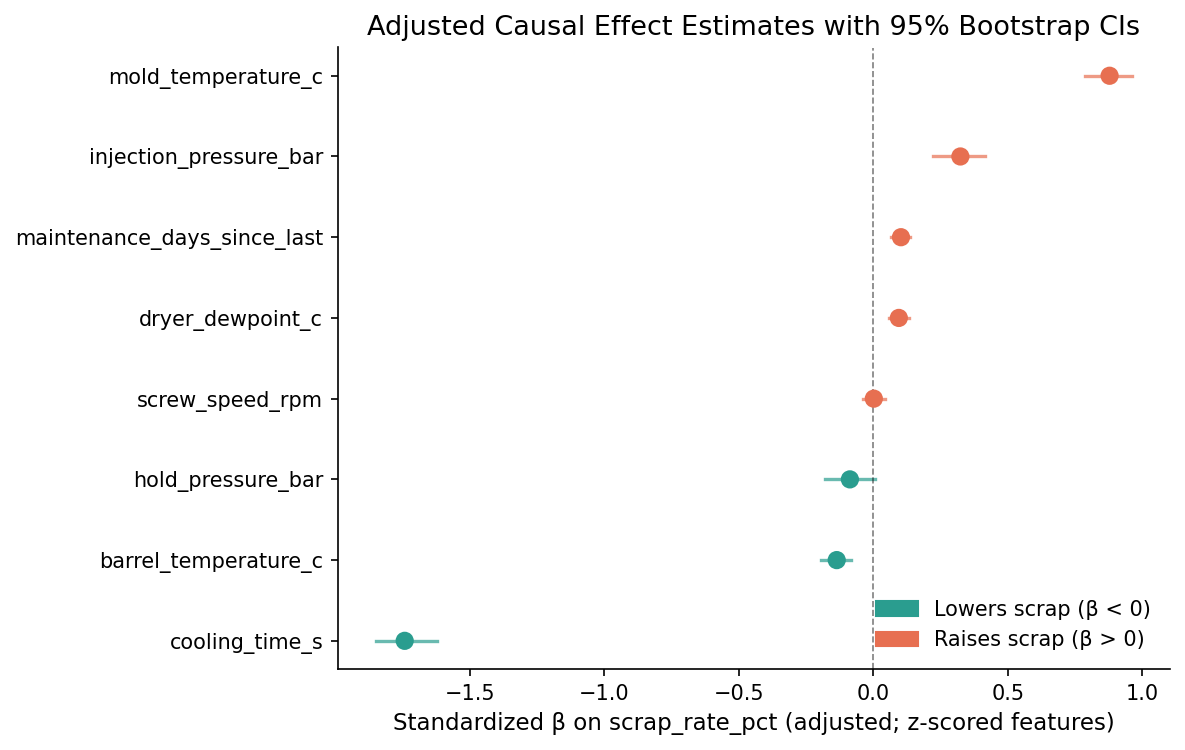

In [6]:
fig = plot_forest(effects_df[["lever", "beta_std", "ci_lo", "ci_hi"]].rename(
    columns={"lever": "variable"}))
plt.show()


## 6. The Cooling-Time Sign Change

This is the central finding of the analysis.

**Raw correlation:** ρ = +0.28 — appears to say more cooling → more scrap.  
**Adjusted estimate:** β = −1.75 (std) — the true effect is strongly protective.

### Mechanism: Reverse causation

Operators already extend cooling *reactively* when they observe high mold temperatures (a sign of elevated thermal stress). The raw positive correlation captures their compensation behaviour, not the direct effect of cooling on scrap. Conditioning on `mold_temperature_c` (and the other confounders in the adjustment set) removes this bias and reveals the true protective effect.

> A predictive pipeline acting on the raw signal would recommend *shortening* cooling — the opposite of the correct direction.


Saved → /Users/abdulrahmanahmad/Desktop/My Projects/Datathon/repo/figures/cooling_sign_reversal.png


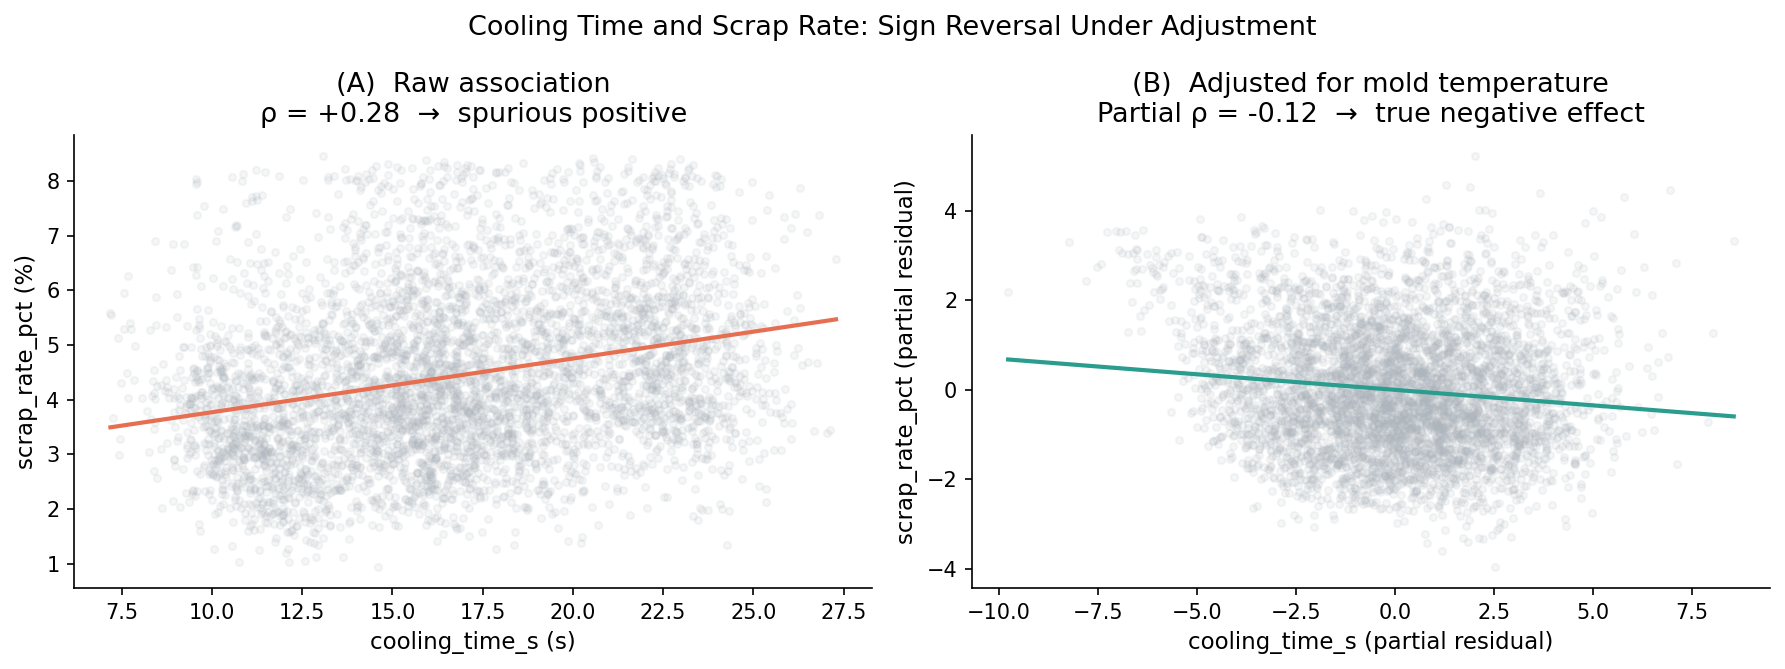

In [7]:
fig = plot_cooling_sign_reversal(df)
plt.show()


In [8]:
# Quantitative summary of the sign change
from scipy import stats
rho_raw, _ = stats.pearsonr(df["cooling_time_s"], df["scrap_rate_pct"])
from sklearn.linear_model import LinearRegression
import numpy as np

X = df[["mold_temperature_c"]].values
reg_y = LinearRegression().fit(X, df["scrap_rate_pct"].values)
reg_c = LinearRegression().fit(X, df["cooling_time_s"].values)
resid_y = df["scrap_rate_pct"].values - reg_y.predict(X)
resid_c = df["cooling_time_s"].values - reg_c.predict(X)
rho_partial, _ = stats.pearsonr(resid_c, resid_y)

cooling_row = effects_df[effects_df["lever"] == "cooling_time_s"].iloc[0]
print(f"Raw correlation (cooling vs scrap):       ρ = {rho_raw:+.3f}")
print(f"Partial correlation (adj. mold temp):     ρ = {rho_partial:+.3f}")
print(f"Full adjusted β (standardized):           β = {cooling_row['beta_std']:+.3f}")
print(f"  95% CI:  [{cooling_row['ci_lo']:+.3f}, {cooling_row['ci_hi']:+.3f}]")
print(f"Natural-unit effect:                      β̃ = {cooling_row['beta_unstd']:+.4f} p.p./s")
print()
print("Worked example — extending cooling by +1.5 s:")
delta_linear = cooling_row["beta_unstd"] * 1.5
print(f"  Linear estimate: {cooling_row['beta_unstd']:.4f} × 1.5 = {delta_linear:.3f} p.p.")


Raw correlation (cooling vs scrap):       ρ = +0.278
Partial correlation (adj. mold temp):     ρ = -0.122
Full adjusted β (standardized):           β = -1.743
  95% CI:  [-1.851, -1.622]
Natural-unit effect:                      β̃ = -0.6157 p.p./s

Worked example — extending cooling by +1.5 s:
  Linear estimate: -0.6157 × 1.5 = -0.924 p.p.


## 7. Warpage Interaction: Mold Temperature × Cooling Time

The protective effect of cooling is not uniform. It is amplified at high mold temperatures — precisely where the thermal problem is worst. We quantify this by estimating an interaction model on the warpage subset.


Saved → /Users/abdulrahmanahmad/Desktop/My Projects/Datathon/repo/figures/warpage_interaction.png


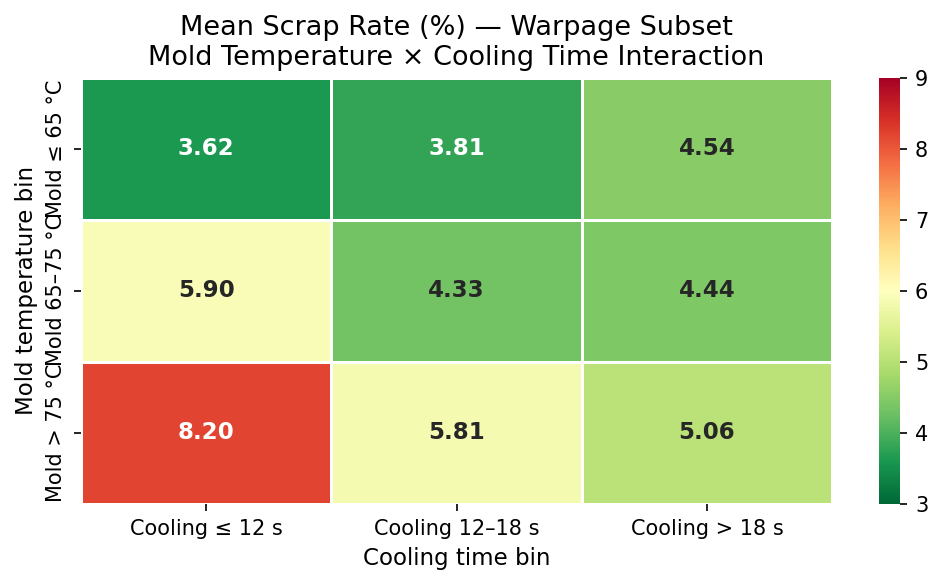

In [9]:
from src.plotting import plot_warpage_interaction
fig = plot_warpage_interaction(df)
plt.show()


In [10]:
# Cross-tabulation
warp = df[df["defect_type"] == "warpage"].copy()
warp["mold_bin"] = pd.cut(warp["mold_temperature_c"],
    bins=[-np.inf, 65, 75, np.inf], labels=["≤ 65 °C", "65–75 °C", "> 75 °C"])
warp["cool_bin"] = pd.cut(warp["cooling_time_s"],
    bins=[-np.inf, 12, 18, np.inf], labels=["≤ 12 s", "12–18 s", "> 18 s"])
pivot = warp.pivot_table(values="scrap_rate_pct", index="mold_bin", columns="cool_bin",
                          aggfunc=["mean", "count"])
pivot.round(3)


mean                 count               
cool_bin ≤ 12 s 12–18 s > 18 s ≤ 12 s 12–18 s > 18 s
mold_bin                                            
≤ 65 °C   3.617   3.807  4.539    231     256     17
65–75 °C  5.898   4.333  4.440     20     372    146
> 75 °C   8.199   5.813  5.060      1     110    497

**Key numbers (mold > 75 °C):**
- Cooling ≤ 12 s → mean scrap **8.2%**
- Cooling > 18 s → mean scrap **5.1%**
- Difference: **−3.1 p.p.** within the warpage subset at high mold temperature

This interaction means the cooling extension is most valuable for machines already running hot molds. The deployment plan in Notebook 03 accounts for this.


## 8. Two Effects Disclosed but Not Actioned

### Operator experience level (β ≈ +0.12)

The adjusted regression shows a small positive β for operator experience. The most defensible interpretation is **residual assignment bias**: senior operators are staffed to harder shifts, more demanding variants, and new tool runs. Shift and variant fixed effects absorb part of this, but the residual persists. Because the observed association is not attributable to a direct causal effect of operator experience on scrap, no intervention follows.

### Hold pressure (β ≈ −0.09, CI crosses zero)

Hold pressure is mildly protective and consistent with process theory (adequate hold reduces sink marks and dimensional deviation). However, its 95% CI narrowly includes zero. It is tracked in the effect table but excluded from the primary action package on grounds of borderline significance.


## 9. Summary

| Lever | β (std) | Direction | Actioned? |
|---|---|---|---|
| `cooling_time_s` | −1.75 | Extend | ✅ High confidence |
| `mold_temperature_c` | +0.88 | Cap | ✅ Med–High confidence |
| `injection_pressure_bar` | +0.31 | Reduce (conditional) | ✅ Medium confidence |
| `tool_wear_index` | +0.25 | Via maintenance | ✅ Indirect |
| `dryer_dewpoint_c` | +0.09 | Lower (conditional) | ✅ Medium confidence |
| `maintenance_days_since_last` | +0.10 | Shorten interval | ✅ Medium confidence |
| `barrel_temperature_c` | −0.13 | — | ⚠️ Small effect |
| `hold_pressure_bar` | −0.09 | — | ⚠️ CI crosses zero |
| `screw_speed_rpm` | +0.01 | — | ❌ No effect |
| `operator_experience_level` | +0.12 | — | ❌ Assignment bias |

**Next:** Notebook 03 runs the counterfactual simulation, sizes the interventions, and evaluates trade-offs.
